In [30]:
import importlib

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from myModeler import myModel
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader, Subset
import math
import util
importlib.reload(util)


<module 'util' from 'c:\\Users\\Ataka\\dev\\util.py'>

In [ ]:
print(torch.cuda.is_available())

#from google.colab import drive 
#drive.mount('/content/drive')


# Veri setini (MNIST - El yazısı rakamlar) indiriyoruz ve normalize ediyoruz
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

train_and_validation_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)


test_dataset = datasets.CIFAR10(root='./data', train=False, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

num_train = len(train_and_validation_dataset) # 50000
indices = list(range(num_train))
split = 5000 # Validation için ayrılacak miktar

# İndeksleri karıştır (Shuffle)
np.random.seed(42) # Her seferinde aynı bölünme olması için
np.random.shuffle(indices)

train_idx, val_idx = indices[split:], indices[:split]

# Subset'leri oluştur
train_subset = Subset(train_and_validation_dataset, train_idx)
val_subset = Subset(train_and_validation_dataset, val_idx)

train_loader = DataLoader(train_subset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=64, shuffle=False)



True
Files already downloaded and verified


c:\Users\Ataka\miniconda3\envs\ai_dev\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [3]:

model = myModel()
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Toplam Parametre: {total_params}")
print(f"Eğitilebilir Parametre: {trainable_params}")

# 1. GPU kullanılabilir mi kontrol et
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Kullanılan cihaz: {device}")

# 2. Modelin nerede olduğuna bak
# model.parameters() içindeki ilk ağırlığın cihazına bakarız
print(f"Model şu an şurada: {next(model.parameters()).device}")

model.to(device)

# 2. Modelin nerede olduğuna bak
# model.parameters() içindeki ilk ağırlığın cihazına bakarız
print(f"Model şu an şurada: {next(model.parameters()).device}")

# criterion
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-3)

criterion.to(device)

Toplam Parametre: 364618
Eğitilebilir Parametre: 364618
Kullanılan cihaz: cuda
Model şu an şurada: cpu
Model şu an şurada: cuda:0


CrossEntropyLoss()

In [ ]:
epochs = 20 # Verinin üzerinden kaç kez geçileceği
gradients = [[],[],[],[],[]]
train_losses=[]
val_losses=[]
val_accuracies=[]

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        # 1. Gradyanları sıfırla
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()

        # 2. Forward pass: Tahmin yap
        outputs = model(images)

        # 3. Kaybı (hata oranını) hesapla
        loss = criterion(outputs, labels)

        # 4. Backward pass: Hatayı geriye yay ve ağırlıkları güncelle
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        

    #print(f"Epoch {epoch+1} - Kayıp: {running_loss/len(train_loader)}")

    counter = 0
    for name, param in model.named_parameters():
        if param.grad is not None and counter < 10:
            #print(f"{name} gradient mean: {param.grad.abs().mean().item()}")
            if counter %2 ==0:  
                gradients[math.floor(counter/2)].append(param.grad.abs().mean().item())
            counter += 1

    # --- DOĞRULAMA (VALIDATION) AŞAMASI ---
    model.eval() # Modeli değerlendirme moduna al (Dropout ve BatchNorm pasif)
    val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad(): # Gradyan hesaplamayı kapat (Hafıza tasarrufu ve hız sağlar)
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            
            # Accuracy hesaplama
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    # Epoch sonu ortalama değerleri hesapla
    avg_train_loss = running_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)
    val_acc = 100 * correct / total

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    val_accuracies.append(val_acc)

    print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}, Val Acc: %{val_acc:.2f}')

print("Eğitim Tamamlandı!")

Epoch [1/30], Train Loss: 1.4434, Val Loss: 1.0937, Val Acc: %62.06
Epoch [2/30], Train Loss: 1.0697, Val Loss: 0.9605, Val Acc: %65.78
Epoch [3/30], Train Loss: 0.9348, Val Loss: 0.8577, Val Acc: %69.82
Epoch [4/30], Train Loss: 0.8501, Val Loss: 0.7833, Val Acc: %73.08
Epoch [5/30], Train Loss: 0.7811, Val Loss: 0.8281, Val Acc: %71.68
Epoch [6/30], Train Loss: 0.7360, Val Loss: 0.7362, Val Acc: %75.18
Epoch [7/30], Train Loss: 0.6910, Val Loss: 0.7415, Val Acc: %74.26
Epoch [8/30], Train Loss: 0.6535, Val Loss: 0.7451, Val Acc: %74.34
Epoch [9/30], Train Loss: 0.6183, Val Loss: 0.6625, Val Acc: %77.36
Epoch [10/30], Train Loss: 0.5898, Val Loss: 0.6994, Val Acc: %75.92
Epoch [11/30], Train Loss: 0.5646, Val Loss: 0.6919, Val Acc: %76.66
Epoch [12/30], Train Loss: 0.5509, Val Loss: 0.7106, Val Acc: %76.30
Epoch [13/30], Train Loss: 0.5216, Val Loss: 0.7039, Val Acc: %76.92
Epoch [14/30], Train Loss: 0.5086, Val Loss: 0.6996, Val Acc: %76.86
Epoch [15/30], Train Loss: 0.4868, Val Loss

KeyboardInterrupt: 

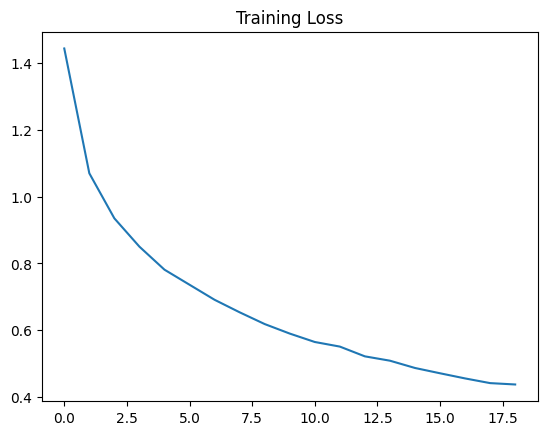

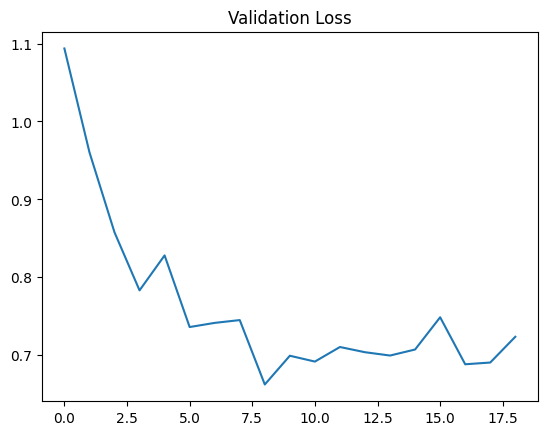

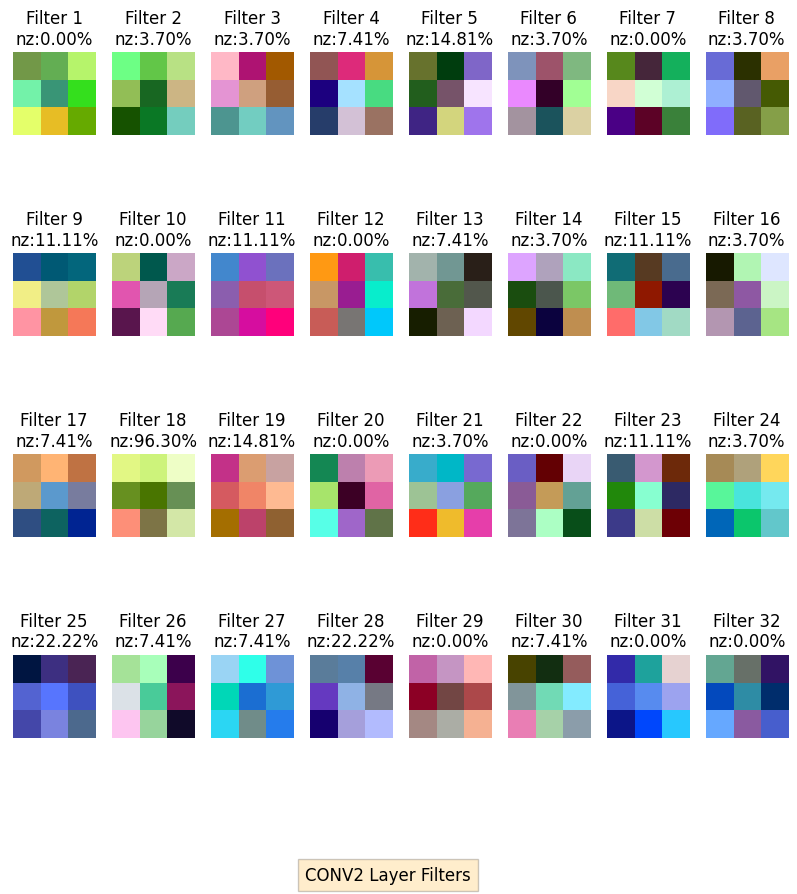

In [32]:
"""plt.figure(figsize=(8, 20)) # Boyutu dikeyde uzun tutuyoruz

plt.subplot(5, 1, 1) # 5 satır, 1 sütun, 1. grafik
plt.plot(np.arange(len(gradients[0])),gradients[0])
plt.title(list(model.named_parameters())[0][0])

plt.subplot(5, 1, 2) # 5 satır, 1 sütun, 2. grafik
plt.plot(np.arange(len(gradients[1])),gradients[1])
plt.title(list(model.named_parameters())[2][0])

plt.subplot(5, 1, 3) # 5 satır, 1 sütun, 3. grafik
plt.plot(np.arange(len(gradients[2])),gradients[2])
plt.title(list(model.named_parameters())[4][0])

plt.subplot(5, 1, 4) # 5 satır, 1 sütun, 4. grafik
plt.plot(np.arange(len(gradients[3])),gradients[3])
plt.title(list(model.named_parameters())[6][0])

plt.subplot(5, 1, 5) # 5 satır, 1 sütun, 5. grafik
plt.plot(np.arange(len(gradients[4])),gradients[4])
plt.title(list(model.named_parameters())[8][0])
plt.legend()
plt.show()"""


#PLOT TRAININGLOSS
plt.plot(train_losses)
plt.title('Training Loss')
plt.show()

#PLOT VALIDATION LOSS
plt.plot(val_losses)
plt.title('Validation Loss')
plt.show()

#PLOT FILTERS
weights = model.conv2.weight.data.cpu()
fig = plt.figure(figsize=(10, 10))
for i in range(weights.shape[0]):
    plt.subplot(math.ceil(weights.shape[0]/8), 8, i+1) # Filtre sayısına göre düzenle
    # Filtreyi normalize et ve görselleştir
    num_close_zeros = util.find_close_zeros(weights[i], threshold=0.01)
    #ax.set_title(f"Number of Close Zeros: {num_close_zeros}", y=-0.3, fontsize=10)
    normalized_weights = util.normalize_filter(weights[i])
    plt.imshow(normalized_weights.numpy().transpose(1, 2, 0))
    plt.title(f'Filter {i+1}\nnz:{num_close_zeros:.2f}%')
    plt.axis('off')
plt.figtext(0.5, 0.01, "CONV2 Layer Filters", 
            ha="center", fontsize=12, bbox={"facecolor":"orange", "alpha":0.2, "pad":5})
plt.show()


In [6]:
from modulefinder import test
def check_accuracy(loader, model):
    num_correct = 0
    num_samples = 0
    model.eval()  # Modeli değerlendirme moduna al (dropout vb. varsa kapatır)

    with torch.no_grad(): # Gradyan hesaplamayı kapat (hafıza tasarrufu sağlar)
        for x, y in loader:
            # Tahmin yap
            x, y = x.to(device), y.to(device)
            scores = model(x)
            _, predictions = scores.max(1) # En yüksek skorlu sınıfı seç

            num_correct += (predictions == y).sum()
            num_samples += predictions.size(0)

    model.train() # Modeli tekrar eğitim moduna döndür
    return float(num_correct) / num_samples * 100

# Kullanımı:
print(f"Test Başarımı: %{check_accuracy(test_loader, model):.2f}")


Test Başarımı: %75.65


In [7]:
# Modelinizin isminin 'SimpleModel' olduğunu varsayalım
# Kaydedilecek dosya yolunu belirleyin (Drive'a bağlıysanız orayı kullanın)
model_path = "myModel.pth"

# Model ağırlıklarını kaydetme
torch.save(model.state_dict(), model_path)
print(f"Model başarıyla şuraya kaydedildi: {model_path}")



# modeli görselleştir.
model.eval()
#model.train()
dummy_input = torch.randn(1, 3, 32, 32).to(device)

onnx_name = "myModel.onnx"

torch.onnx.export(
    model,                      # Eğitilen model
    dummy_input,                # Örnek girdi
    onnx_name,             # Kaydedilecek dosya adı
    export_params=True,         # Eğitilmiş ağırlıkları da içine ekle
    opset_version=11,           # Standart operasyon seti sürümü
    do_constant_folding=True,   # Gereksiz işlemleri optimize et (sadeleştir)
    input_names=['input'],      # Girdi katmanının adı (opsiyonel)
    output_names=['output'],    # Çıktı katmanının adı (opsiyonel)
    dynamic_axes={'input': {0: 'batch_size'}, 'output': {0: 'batch_size'}} # Farklı batch size'lara izin ver
)

print(f"Model başarıyla {onnx_name} olarak kaydedildi!")

Model başarıyla şuraya kaydedildi: myModel.pth
Model başarıyla myModel.onnx olarak kaydedildi!
